In [57]:

import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.integrate import quad


import xobjects as xo
import xtrack as xt
import xpart as xp
import xcoll as xc

import pandas as pd

# Make a context and get a buffer
context = xo.ContextCpu()         # For CPU
# context = xo.ContextCupy()      # For CUDA GPUs
# context = xo.ContextPyopencl()  # For OpenCL GPUs

In [58]:
num_part = int(10000)
x_init = 0.002 * np.ones(num_part)
px_init = np.zeros(num_part)
y_init   = np.zeros(num_part)
py_init  = np.zeros(num_part)

def initialize_particles(context, num_particles=num_part):
    return xp.Particles(
        _context=context,
        x=x_init,  
        px=px_init, 
        y=y_init,
        py=py_init,
        delta=0,
        p0c=4e11
    )
    

In [73]:
# Define the crystal properties (initial values)
length = 0.002
material = xc.materials.SiliconCrystal
bending_angle = 440e-6 / 5
width = 0.002
height = 0.05
side = '+'
miscut = 0.0
lattice = 'strip'
jaw = 0.001

In [74]:
# Dataframe to store particle tracking information
columns = ['iteration', 'particle_id', 'x', 'px']
tracking_data = pd.DataFrame(columns=columns)

In [106]:

min_angle = -20
max_angle = 20
steps = 1
# Define the range of bending angles to iterate over
impacting_angles = [i * 1e-6 for i in range(min_angle, max_angle, steps)]  # Example: 100 µrad to 200 µrad in 10 µrad steps

np.linspace(-20, 20, 10)


array([-20.        , -15.55555556, -11.11111111,  -6.66666667,
        -2.22222222,   2.22222222,   6.66666667,  11.11111111,
        15.55555556,  20.        ])

In [ ]:
# List to collect all tracking data
tracking_data_list = []

# Loop over bending angles
for iteration, angle in enumerate(impacting_angles):
    # Create the crystal with the current bending angle
    coll = xc.EverestCrystal(
        length=length,
        material=material,
        bending_angle=bending_angle,
        width=width,
        height=height,
        side=side,
        miscut=miscut,
        lattice=lattice,
        tilt = angle,    #IMPORTANT
        jaw=jaw,
        _context=context
    )
    
    # Initialize a new beam of particles for this iteration
    part = initialize_particles(context)
    
    # Track particles through the crystal
    coll.track(part)  # Updates the particle states in place
    
    # Collect particle data for this iteration
    for i in range(len(part.x)):
        tracking_data_list.append({
            'iteration': iteration,
            'particle_id': i,
            'x': part.x[i],
            'px': part.px[i],
            'angle': angle
        })
    print(str(iteration))
# Convert the collected data into a DataFrame
tracking_data = pd.DataFrame(tracking_data_list)


0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39


In [77]:
# Perform analysis or save the DataFrame
print(tracking_data.head())


   iteration  particle_id      x        px    angle
0          0            0  0.002 -0.000010 -0.00002
1          0            1  0.002 -0.000015 -0.00002
2          0            2  0.002 -0.000014 -0.00002
3          0            3  0.002 -0.000022 -0.00002
4          0            4  0.002 -0.000014 -0.00002


In [86]:
tracking_data

,iteration,particle_id,x,px,angle
0,0,0,0.002,-9.760382e-06,-0.000020
1,0,1,0.002,-1.535378e-05,-0.000020
2,0,2,0.002,-1.366970e-05,-0.000020
3,0,3,0.002,-2.231967e-05,-0.000020
4,0,4,0.002,-1.386268e-05,-0.000020
...,...,...,...,...,...
399995,39,9995,0.002,-1.943764e-06,0.000019
399996,39,9996,0.002,-1.410012e-06,0.000019
399997,39,9997,0.002,1.353395e-07,0.000019
399998,39,9998,0.002,-3.579839e-06,0.000019


In [104]:
# Define Gaussian function for fitting
def gaussian(x, amp, mean, sigma):
    return amp * np.exp(-((x - mean) ** 2) / (2 * sigma ** 2))

# Initialize required variables
BendingAngle = bending_angle  # Convert to microradians
print(BendingAngle)
efficiencies = []  # List to store calculated efficiencies

# Loop over iterations for efficiency analysis
for iteration in tracking_data['iteration'].unique():
    # Extract data for the current iteration
    iteration_data = tracking_data[tracking_data['iteration'] == iteration]

    if iteration_data['angle'].isnull().any():
        print(f"Iteration {iteration}: Invalid 'angle' data. Skipping.")
        efficiencies.append(np.nan)
        continue

    # Calculate crystal angle
    crystal_angle = iteration_data['angle'].iloc[0] 
    print(crystal_angle)
    # Extract px values
    px_values = iteration_data['px']

    # Generate histogram data
    counts, bin_edges = np.histogram(px_values, bins=200, density=False)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    bin_width = bin_edges[1] - bin_edges[0]

    if len(counts) == 0 or np.max(counts) == 0:
        print(f"Iteration {iteration}: No valid histogram data. Skipping.")
        efficiencies.append(np.nan)
        continue

    # Initialize guesses for Gaussian parameters
    amplitude_guess = max(counts)
    mean_guess = crystal_angle + BendingAngle
    stddev_guess = np.std(px_values) if np.std(px_values) > 0 else bin_width

    initial_guess = [amplitude_guess, mean_guess, stddev_guess]

    # Fit Gaussian to histogram data
    try:
        popt, _ = curve_fit(
            gaussian,
            bin_centers,
            counts,
            p0=initial_guess,
            bounds=([0, BendingAngle * 0.9 + crystal_angle, 1],
                    [np.inf, BendingAngle * 1.1 + crystal_angle, 10])
        )
    except (RuntimeError, ValueError) as e:
        print(f"Iteration {iteration}: Curve fitting failed. Error: {e}")
        efficiencies.append(np.nan)
        continue

    # Calculate efficiency
    amplitude, mean, stddev = popt
    integral_of_fit = amplitude * stddev * np.sqrt(2 * np.pi)  # Integral of the Gaussian
    efficiency = abs(integral_of_fit / (num_part * bin_width))
    efficiencies.append(efficiency)

# Generate impacting angle data
impacting_angle = min_angle + tracking_data['iteration'].unique() * steps

# Save efficiencies to DataFrame
efficiency_data = pd.DataFrame({
    'impacting angle (muRad)': impacting_angle,
    'efficiency': efficiencies
})

# Display efficiency data
print(efficiency_data)


8.8e-05
-1.9999999999999998e-05
Iteration 0: Curve fitting failed. Error: `x0` is infeasible.
-1.8999999999999998e-05
Iteration 1: Curve fitting failed. Error: `x0` is infeasible.
-1.8e-05
Iteration 2: Curve fitting failed. Error: `x0` is infeasible.
-1.7e-05
Iteration 3: Curve fitting failed. Error: `x0` is infeasible.
-1.6e-05
Iteration 4: Curve fitting failed. Error: `x0` is infeasible.
-1.4999999999999999e-05
Iteration 5: Curve fitting failed. Error: `x0` is infeasible.
-1.4e-05
Iteration 6: Curve fitting failed. Error: `x0` is infeasible.
-1.3e-05
Iteration 7: Curve fitting failed. Error: `x0` is infeasible.
-1.2e-05
Iteration 8: Curve fitting failed. Error: `x0` is infeasible.
-1.1e-05
Iteration 9: Curve fitting failed. Error: `x0` is infeasible.
-9.999999999999999e-06
Iteration 10: Curve fitting failed. Error: `x0` is infeasible.
-9e-06
Iteration 11: Curve fitting failed. Error: `x0` is infeasible.
-8e-06
Iteration 12: Curve fitting failed. Error: `x0` is infeasible.
-7e-06
Iter

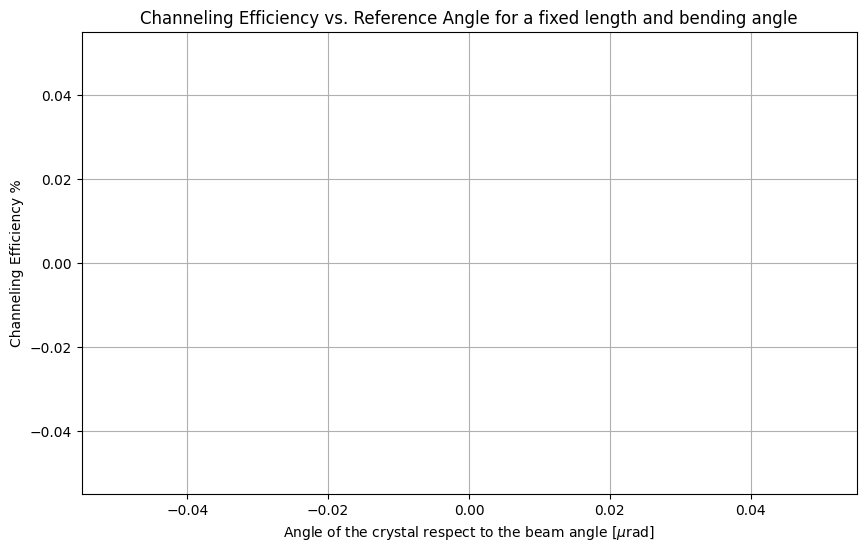

In [103]:
# Ensure efficiencies and bending angles are in the same order
efficiency_data['bending_angle'] = [angle for angle in impacting_angles]  

# Plot Channeling Efficiency vs Bending Angle
plt.figure(figsize=(10, 6))
plt.plot(efficiency_data['bending_angle']*10e5, efficiency_data['efficiency'] * 100, marker='o', linestyle='-')

# Customize the plot
plt.title('Channeling Efficiency vs. Reference Angle for a fixed length and bending angle')
plt.xlabel(r'Angle of the crystal respect to the beam angle [$\mu$rad]')
plt.ylabel('Channeling Efficiency %')
plt.grid(True)
plt.show()

## Tests